In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(
    "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/d13.csv",
    low_memory=False,
    encoding='latin-1'
)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: 19,184,017 rows x 10 cols
Columns: ['MDR_REPORT_KEY', 'YEAR', 'FOI_TEXT', 'TEXT_LENGTH', 'BRAND_NAME', 'GENERIC_NAME', 'DEVICE_REPORT_PRODUCT_CODE', 'MANUFACTURER_D_NAME', 'DEVICE_SEQUENCE_NO', 'DATE_RECEIVED']


,MDR_REPORT_KEY,YEAR,FOI_TEXT,TEXT_LENGTH,BRAND_NAME,GENERIC_NAME,DEVICE_REPORT_PRODUCT_CODE,MANUFACTURER_D_NAME,DEVICE_SEQUENCE_NO,DATE_RECEIVED
0,2094110,2017,mfrs comment the benefitrisk relationship of e...,13811,EPICEL (CULTURED EPIDERMAL AUTOGRAFTS) GRAFT,CULTURED EPIDERMAL AUTOGRAFTS,OCE,GENZYME BIOSURGERY (CAMBRIDGE),28954,2017/01/12
1,2296019,2015,it was reported that the pt is alleging harm c...,2058,NEXGEN LCCK FEMORAL IMPLANT,KNEE PROSTHESIS,JWH,"ZIMMER, INC.",451705,2015/07/13
2,2686192,2015,it was reported by the pts attorney that after...,25055,G2 FILTER SYSTEM - FEMORAL,VENA CAVA FILTER,DTK,"BARD PERIPHERAL VASCULAR, INC.",20222,2015/01/09
3,2893201,2015,this is a supplemental report for mfr report ...,2434,OLYMPUS EVIS EXERA II DUODENOVIDEOSCOPE,DUODENOSCOPE,FDT,OLYMPUS MEDICAL SYSTEMS CORPORATION,309162,2015/05/11
4,4068041,2015,cormet revision after years months c initial...,467,CORMET RESURFACING,METAL ON METAL RE-SURFACING,NXT,"CORIN MEDICAL, LTD.",110085,2015/02/13


In [4]:
print("Dtypes:")
print(df.dtypes)
print(f"\nNull rates:")
print(df.isnull().mean().mul(100).round(1).sort_values(ascending=False))

Dtypes:
MDR_REPORT_KEY                 int64
YEAR                           int64
FOI_TEXT                      object
TEXT_LENGTH                    int64
BRAND_NAME                    object
GENERIC_NAME                  object
DEVICE_REPORT_PRODUCT_CODE    object
MANUFACTURER_D_NAME           object
DEVICE_SEQUENCE_NO            object
DATE_RECEIVED                 object
dtype: object

Null rates:
BRAND_NAME                    0.8
MANUFACTURER_D_NAME           0.8
GENERIC_NAME                  0.7
DEVICE_REPORT_PRODUCT_CODE    0.3
DEVICE_SEQUENCE_NO            0.3
DATE_RECEIVED                 0.3
MDR_REPORT_KEY                0.0
YEAR                          0.0
FOI_TEXT                      0.0
TEXT_LENGTH                   0.0
dtype: float64


In [9]:
df['DEVICE_REPORT_PRODUCT_CODE'].nunique()

3726

In [21]:
print(df['DEVICE_REPORT_PRODUCT_CODE'].value_counts().to_string())


DEVICE_REPORT_PRODUCT_CODE
DZE    3316078
QBJ    1775865
FRN    1520687
QFG    1003156
OZP     801846
OYC     787434
OZO     416746
LZG     371072
PQF     301390
LGW     272154
BZD     251230
NBW     250506
MDS     227311
LWS     218525
DTB     205295
FTR     193029
NVN     180365
MKJ     170820
FPA     163142
CBK     159009
QLG     142396
DSQ     137321
GDW     130694
LWP     124667
MVK     121091
NIK     116551
JWH     114417
PZE     111243
FTL     107750
FWM     100269
NVY      96506
MGB      87686
NAY      87486
GEI      71303
FKX      70295
HHS      70043
NVZ      67456
NPT      66505
LKK      65193
BRY      63042
LPH      62548
EZW      61736
LXH      58089
NIQ      57815
FDF      53663
KWA      52715
FET      50524
FDS      48270
MCM      47153
OWB      46663
DSP      44273
JKA      43447
FMF      43152
JDI      43126
GAM      43041
MNT      42448
HWE      41761
KDJ      41428
MIH      40654
BSZ      40222
GCJ      40048
HWC      39605
JJE      39602
FOZ      38002
OJX      3729

In [3]:
df['DATE_RECEIVED'] = pd.to_datetime(df['DATE_RECEIVED'], errors='coerce')

# Extract month and year from DATE_RECEIVED
df['COMPLAINT_YEAR'] = df['DATE_RECEIVED'].dt.year
df['COMPLAINT_MONTH'] = df['DATE_RECEIVED'].dt.month
df['COMPLAINT_YEARMONTH'] = df['DATE_RECEIVED'].dt.to_period('M')

print("Date columns created!")
print(df[['DATE_RECEIVED', 'COMPLAINT_YEAR', 'COMPLAINT_MONTH']].head())

Date columns created!
  DATE_RECEIVED  COMPLAINT_YEAR  COMPLAINT_MONTH
0    2017-01-12          2017.0              1.0
1    2015-07-13          2015.0              7.0
2    2015-01-09          2015.0              1.0
3    2015-05-11          2015.0              5.0
4    2015-02-13          2015.0              2.0


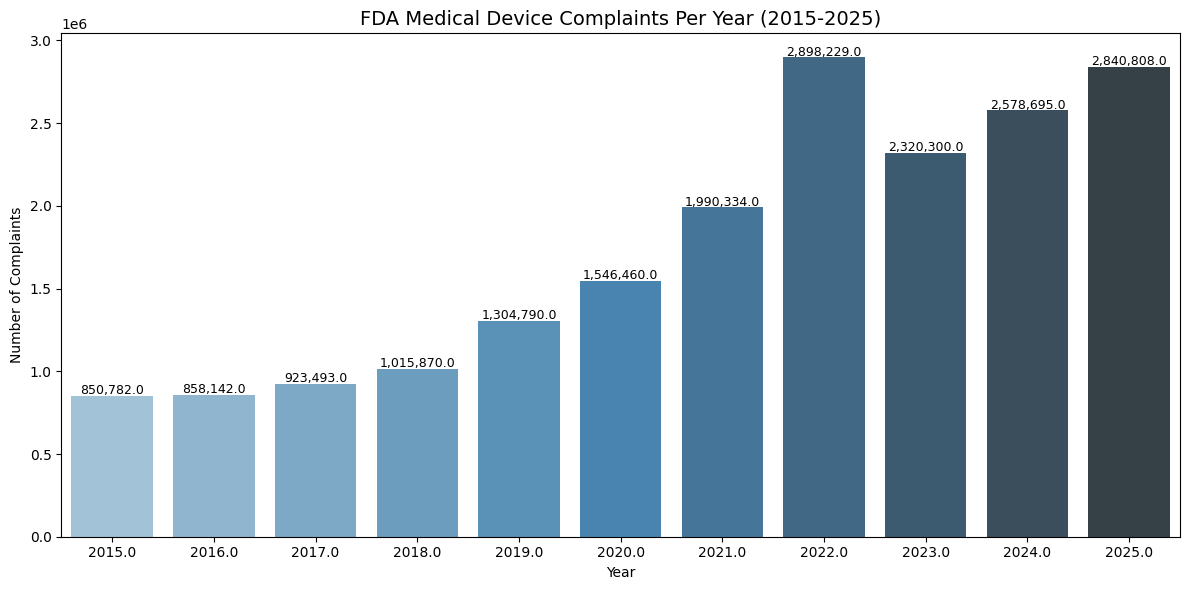

In [12]:
yearly = df.groupby('COMPLAINT_YEAR').size().reset_index(name='complaint_count')
yearly = yearly[yearly['COMPLAINT_YEAR'].between(2015, 2025)]

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=yearly, x='COMPLAINT_YEAR', y='complaint_count', palette='Blues_d')
plt.title('FDA Medical Device Complaints Per Year (2015-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Complaints')

# Add value labels
for i, row in yearly.iterrows():
    plt.text(i, row['complaint_count'] + 10000,
             f"{row['complaint_count']:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('complaints_per_year.png', dpi=150)
plt.show()

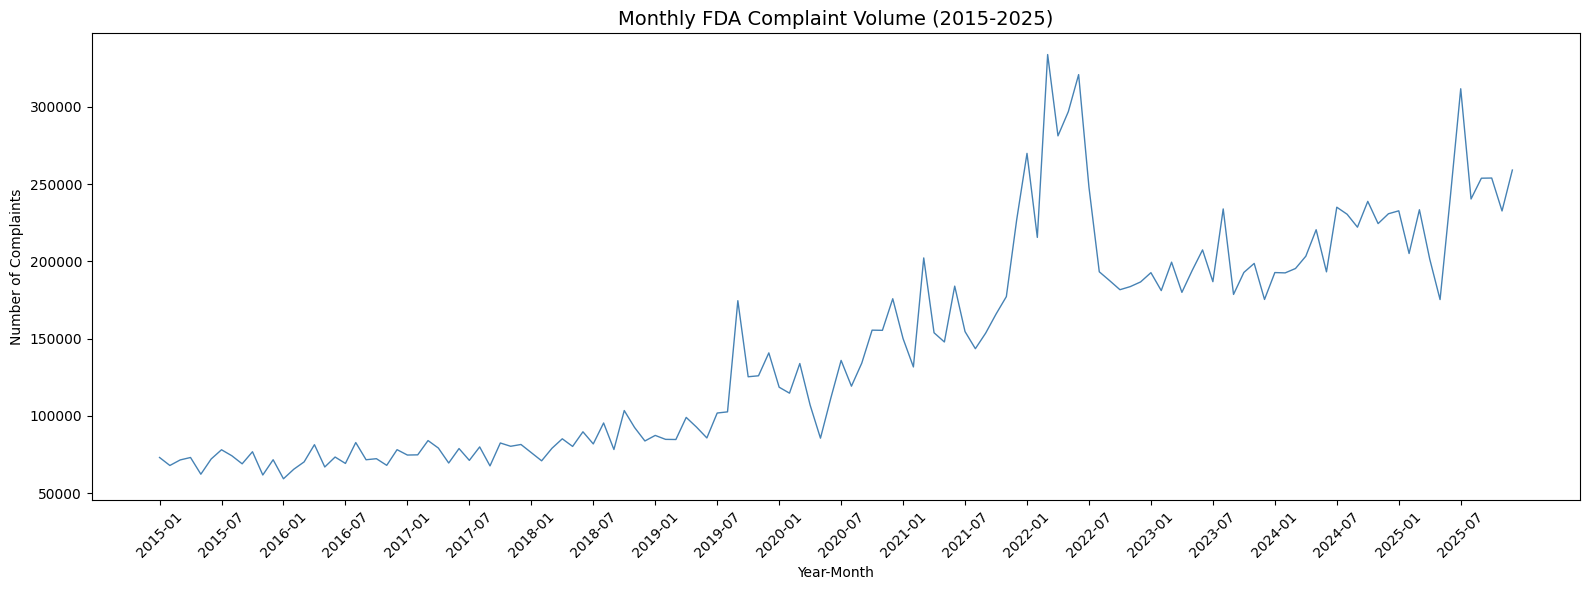

In [13]:
monthly = df.groupby('COMPLAINT_YEARMONTH').size().reset_index(name='count')
monthly['COMPLAINT_YEARMONTH'] = monthly['COMPLAINT_YEARMONTH'].astype(str)

plt.figure(figsize=(16, 6))
plt.plot(monthly['COMPLAINT_YEARMONTH'], monthly['count'], color='steelblue', linewidth=1)
plt.title('Monthly FDA Complaint Volume (2015-2025)', fontsize=14)
plt.xlabel('Year-Month')
plt.ylabel('Number of Complaints')
plt.xticks(monthly['COMPLAINT_YEARMONTH'][::6], rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

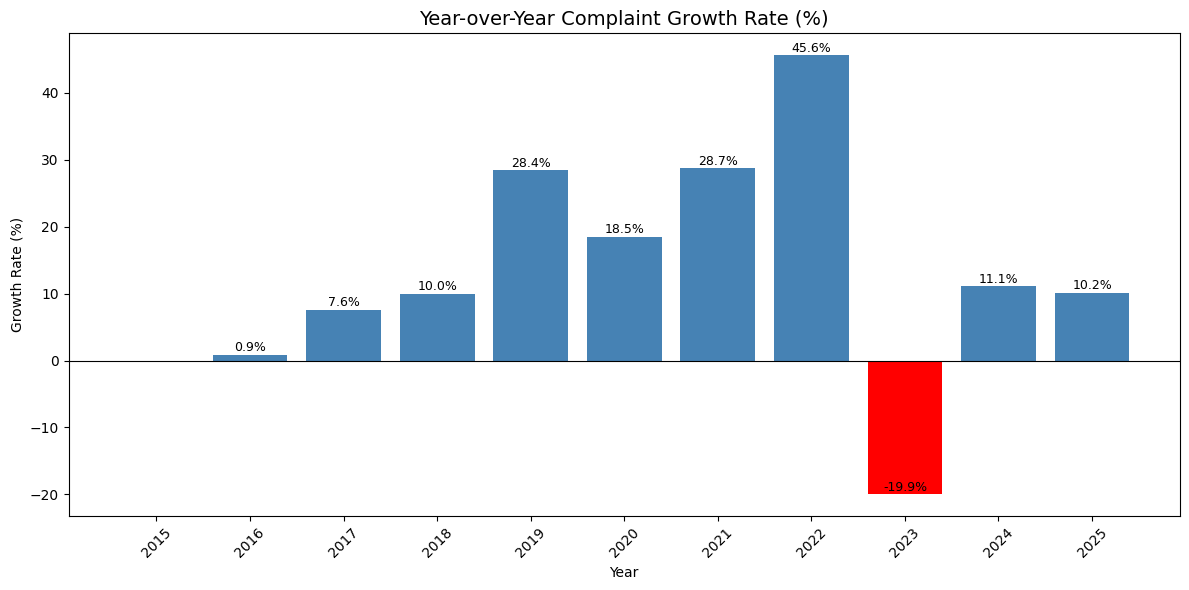

    COMPLAINT_YEAR  complaint_count  YOY_GROWTH
0           2015.0           850782         NaN
1           2016.0           858142    0.865086
2           2017.0           923493    7.615406
3           2018.0          1015870   10.002999
4           2019.0          1304790   28.440647
5           2020.0          1546460   18.521754
6           2021.0          1990334   28.702585
7           2022.0          2898229   45.615208
8           2023.0          2320300  -19.940764
9           2024.0          2578695   11.136275
10          2025.0          2840808   10.164560


In [14]:
yearly['YOY_GROWTH'] = yearly['complaint_count'].pct_change() * 100

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'steelblue' for x in yearly['YOY_GROWTH'].fillna(0)]
plt.bar(yearly['COMPLAINT_YEAR'], yearly['YOY_GROWTH'].fillna(0), color=colors)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Year-over-Year Complaint Growth Rate (%)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.xticks(yearly['COMPLAINT_YEAR'], rotation=45)

for i, row in yearly.iterrows():
    val = row['YOY_GROWTH']
    if pd.notna(val):
        plt.text(row['COMPLAINT_YEAR'], val + 0.5,
                 f"{val:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('yoy_growth.png', dpi=150)
plt.show()

print(yearly[['COMPLAINT_YEAR', 'complaint_count', 'YOY_GROWTH']].to_string())

In [26]:
print(f"Total rows: {df.shape[0]:,}")
matched = df['DEVICE_REPORT_PRODUCT_CODE'].notna().sum()
print(f"Matched rows: {matched:,}")
print(f"Match rate: {matched/df.shape[0]*100:.1f}%")

Total rows: 19,184,017
Matched rows: 19,127,706
Match rate: 99.7%


In [25]:
print(df['DEVICE_REPORT_PRODUCT_CODE'].value_counts().sum())

19127706


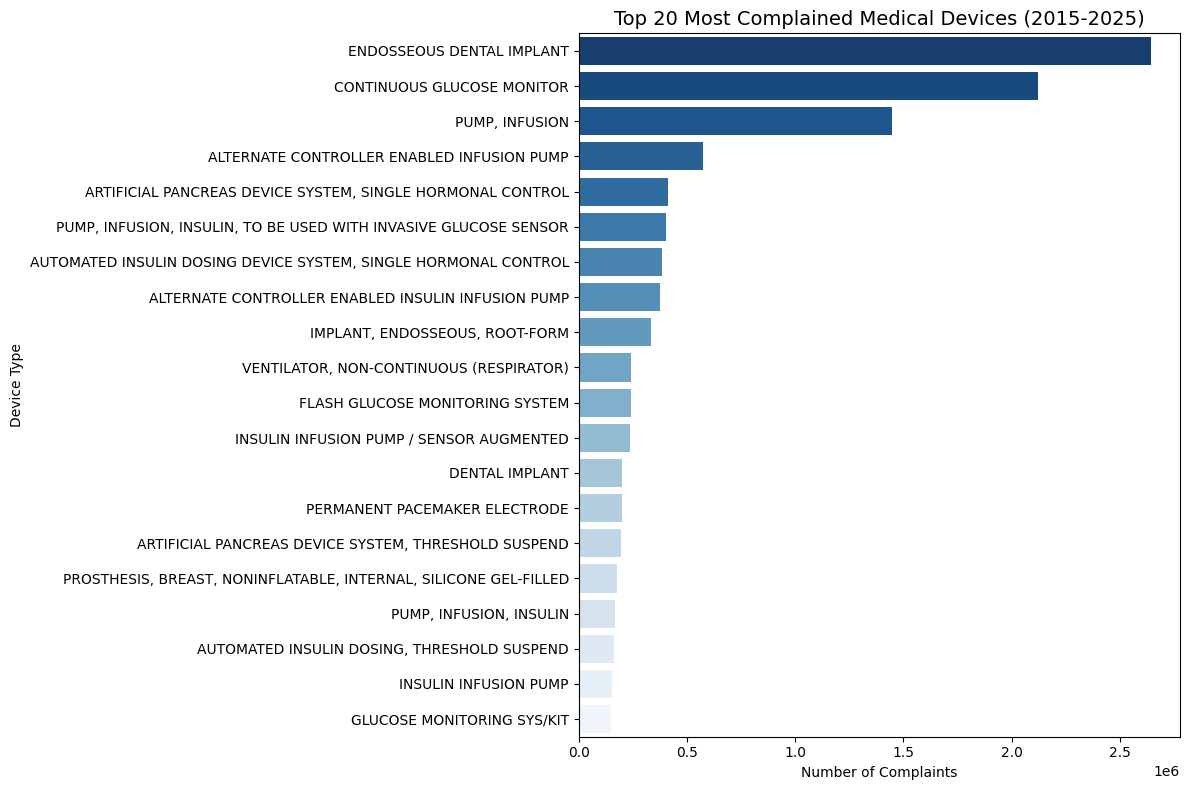

                                                           GENERIC_NAME  complaint_count
28983                                         ENDOSSEOUS DENTAL IMPLANT          2646045
19221                                        CONTINUOUS GLUCOSE MONITOR          2122060
67278                                                    PUMP, INFUSION          1447939
5628                         ALTERNATE CONTROLLER ENABLED INFUSION PUMP           576563
8104         ARTIFICIAL PANCREAS DEVICE SYSTEM, SINGLE HORMONAL CONTROL           413343
67353  PUMP, INFUSION, INSULIN, TO BE USED WITH INVASIVE GLUCOSE SENSOR           401932
8961    AUTOMATED INSULIN DOSING DEVICE SYSTEM, SINGLE HORMONAL CONTROL           383587
5651                 ALTERNATE CONTROLLER ENABLED INSULIN INFUSION PUMP           375242
40867                                    IMPLANT, ENDOSSEOUS, ROOT-FORM           332444
90007                           VENTILATOR, NON-CONTINUOUS (RESPIRATOR)           244112
32402                

In [4]:
# Top 20 generic devices by complaint count
top_generic = df.groupby('GENERIC_NAME').size()\
    .reset_index(name='complaint_count')\
    .sort_values('complaint_count', ascending=False)\
    .head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_generic, x='complaint_count', y='GENERIC_NAME', palette='Blues_r')
plt.title('Top 20 Most Complained Medical Devices (2015-2025)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Device Type')
plt.tight_layout()
plt.savefig('top_generic_devices.png', dpi=150)
plt.show()

print(top_generic.to_string())

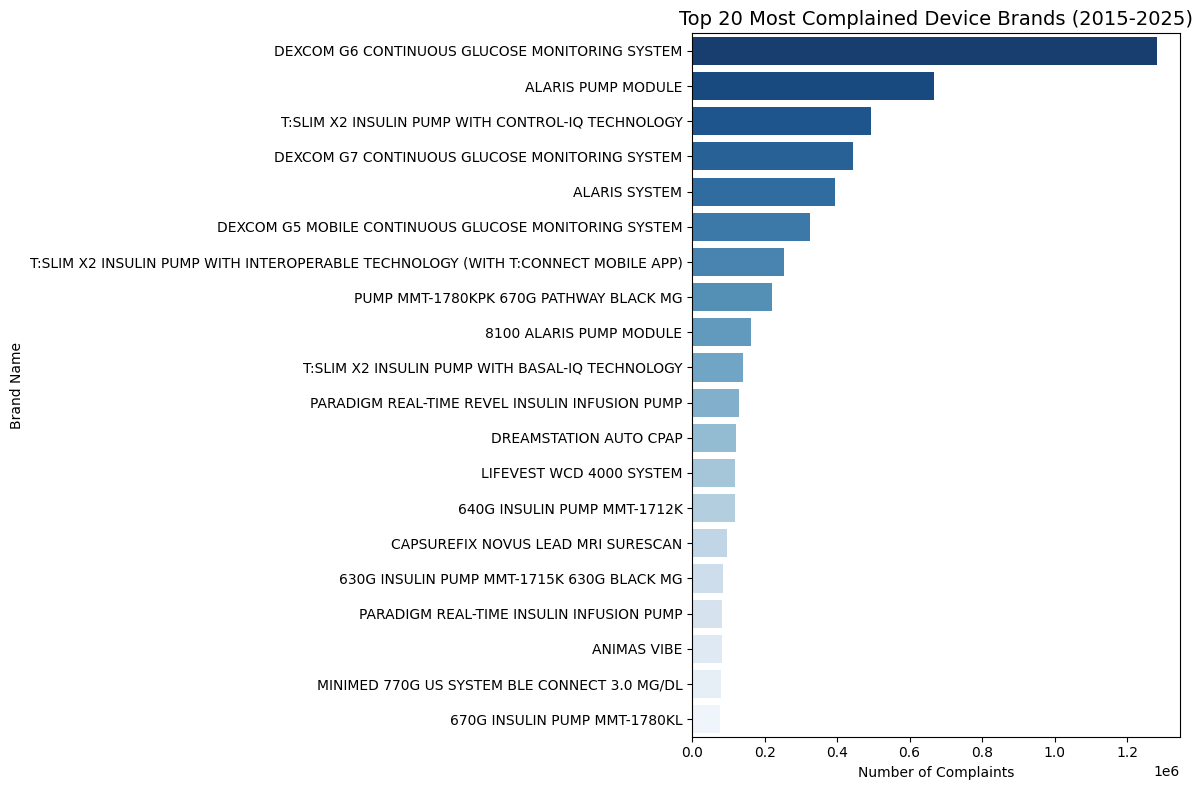

In [5]:
top_brand = df.groupby('BRAND_NAME').size()\
    .reset_index(name='complaint_count')\
    .sort_values('complaint_count', ascending=False)\
    .head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_brand, x='complaint_count', y='BRAND_NAME', palette='Blues_r')
plt.title('Top 20 Most Complained Device Brands (2015-2025)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Brand Name')
plt.tight_layout()
plt.savefig('top_brand_devices.png', dpi=150)
plt.show()

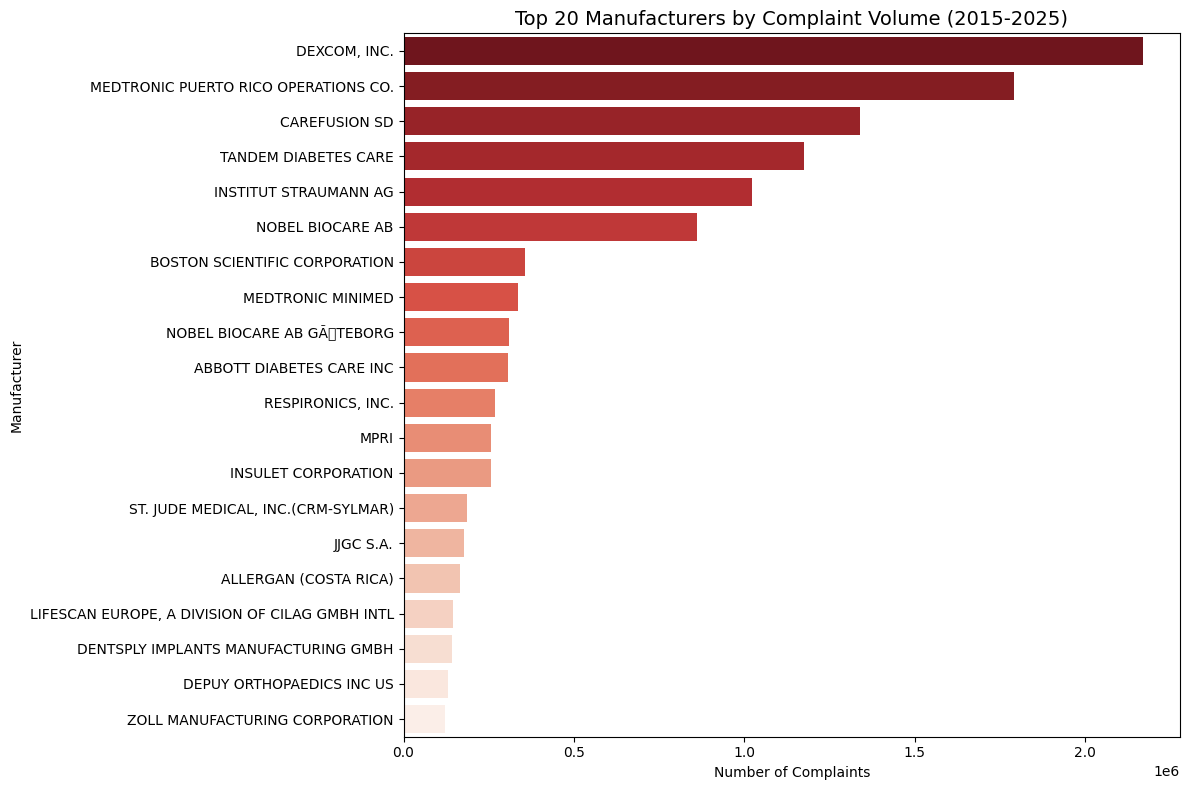

In [6]:
top_mfr = df.groupby('MANUFACTURER_D_NAME').size()\
    .reset_index(name='complaint_count')\
    .sort_values('complaint_count', ascending=False)\
    .head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_mfr, x='complaint_count', y='MANUFACTURER_D_NAME', palette='Reds_r')
plt.title('Top 20 Manufacturers by Complaint Volume (2015-2025)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.savefig('top_manufacturers.png', dpi=150)
plt.show()

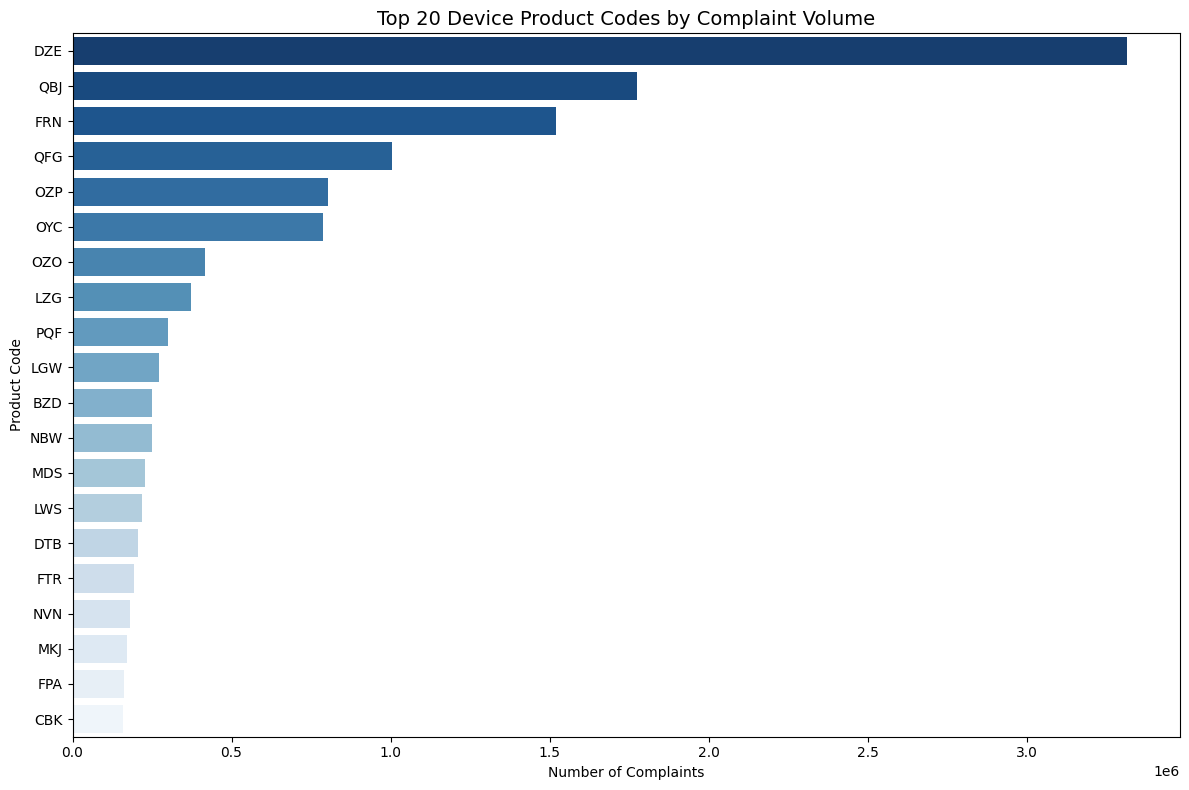

In [7]:
top_codes = df.groupby('DEVICE_REPORT_PRODUCT_CODE').size()\
    .reset_index(name='complaint_count')\
    .sort_values('complaint_count', ascending=False)\
    .head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_codes, x='complaint_count', y='DEVICE_REPORT_PRODUCT_CODE', palette='Blues_r')
plt.title('Top 20 Device Product Codes by Complaint Volume', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Product Code')
plt.tight_layout()
plt.savefig('top_product_codes.png', dpi=150)
plt.show()

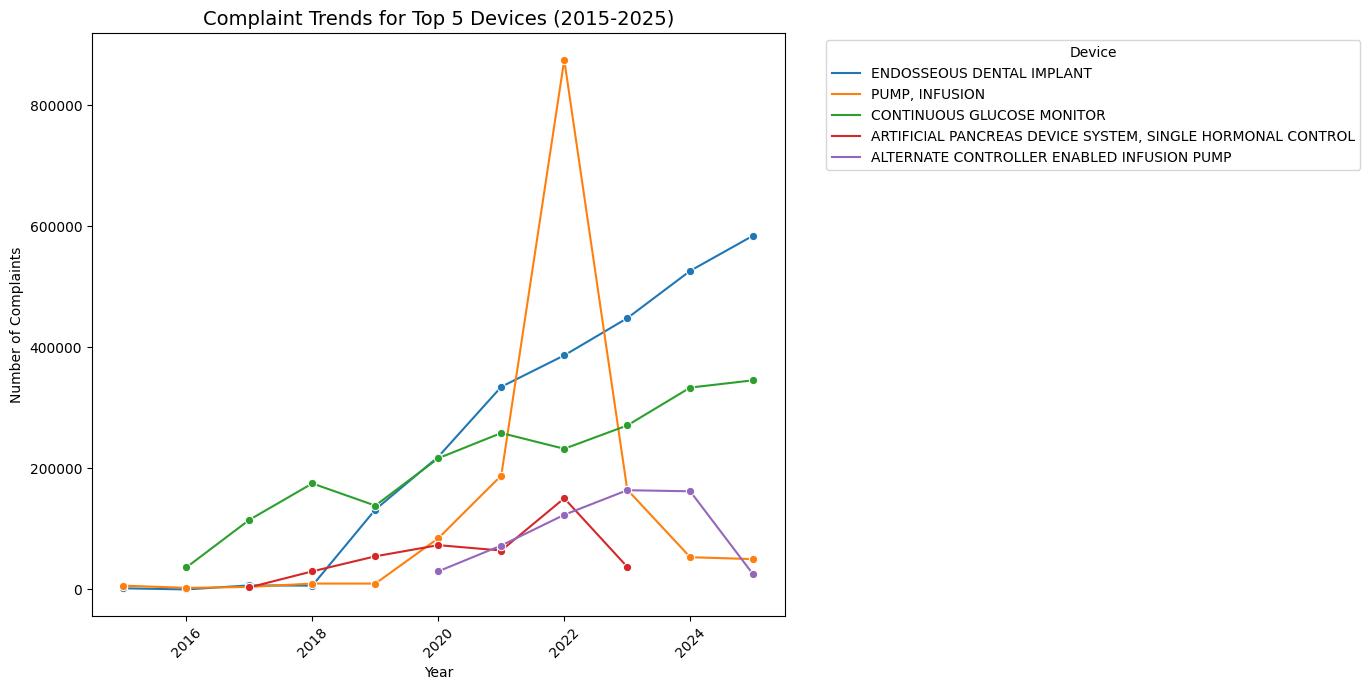

In [8]:
top5_devices = top_generic['GENERIC_NAME'].head(5).tolist()

# Filter and group by year
device_trends = df[df['GENERIC_NAME'].isin(top5_devices)]\
    .groupby(['YEAR', 'GENERIC_NAME']).size()\
    .reset_index(name='count')

plt.figure(figsize=(14, 7))
sns.lineplot(data=device_trends, x='YEAR', y='count', 
             hue='GENERIC_NAME', marker='o')
plt.title('Complaint Trends for Top 5 Devices (2015-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.legend(title='Device', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top5_device_trends.png', dpi=150)
plt.show()

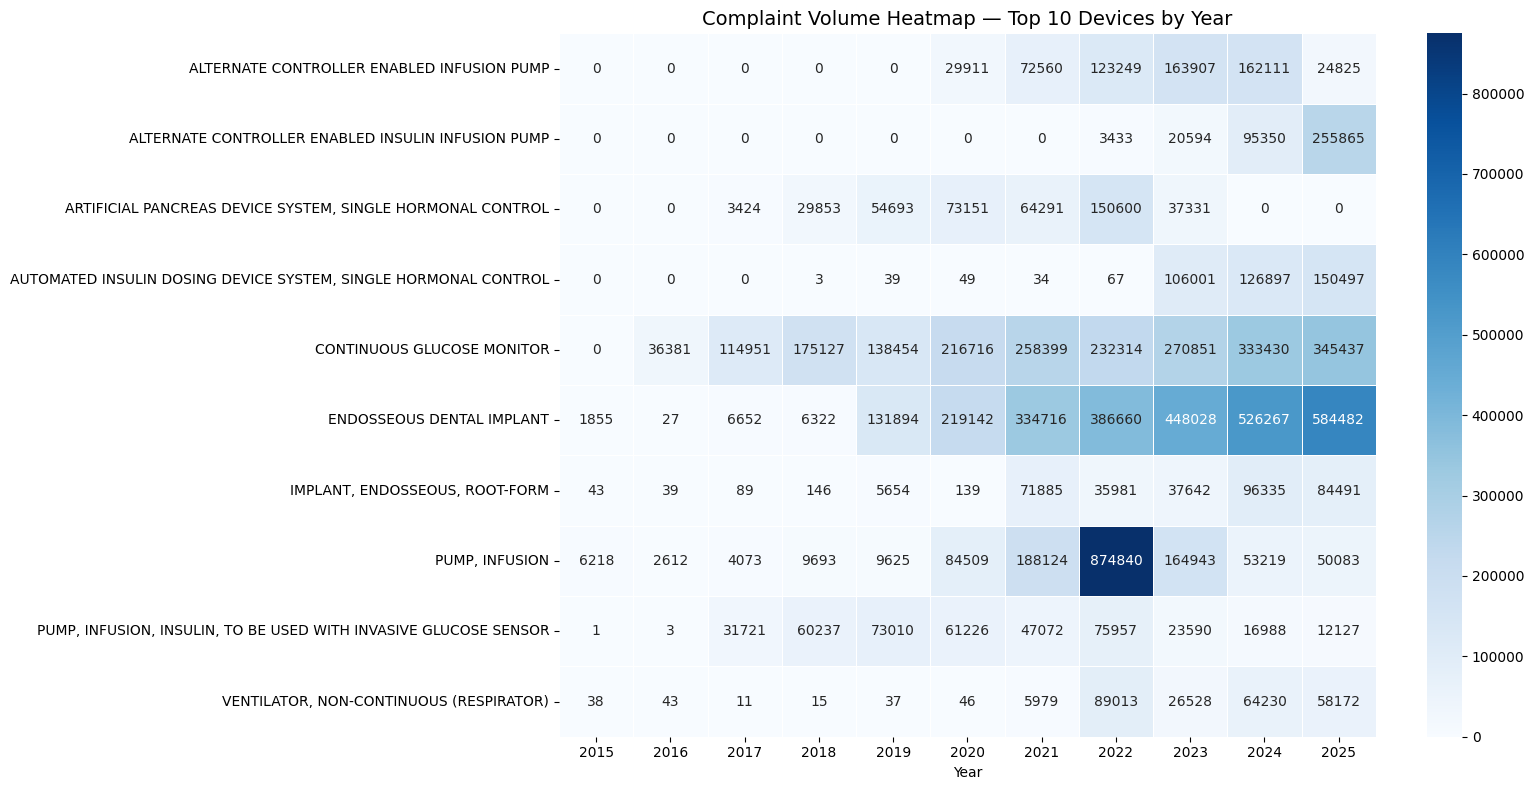

In [11]:
# Pivot table for heatmap
top10_devices = top_devices['GENERIC_NAME'].head(10).tolist()

heatmap_data = df[df['GENERIC_NAME'].isin(top10_devices)]\
    .groupby(['YEAR', 'GENERIC_NAME']).size()\
    .reset_index(name='count')\
    .pivot(index='GENERIC_NAME', columns='YEAR', values='count')\
    .fillna(0)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', 
            cmap='Blues', linewidths=0.5)
plt.title('Complaint Volume Heatmap — Top 10 Devices by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('')
plt.tight_layout()
plt.savefig('device_heatmap.png', dpi=150)
plt.show()

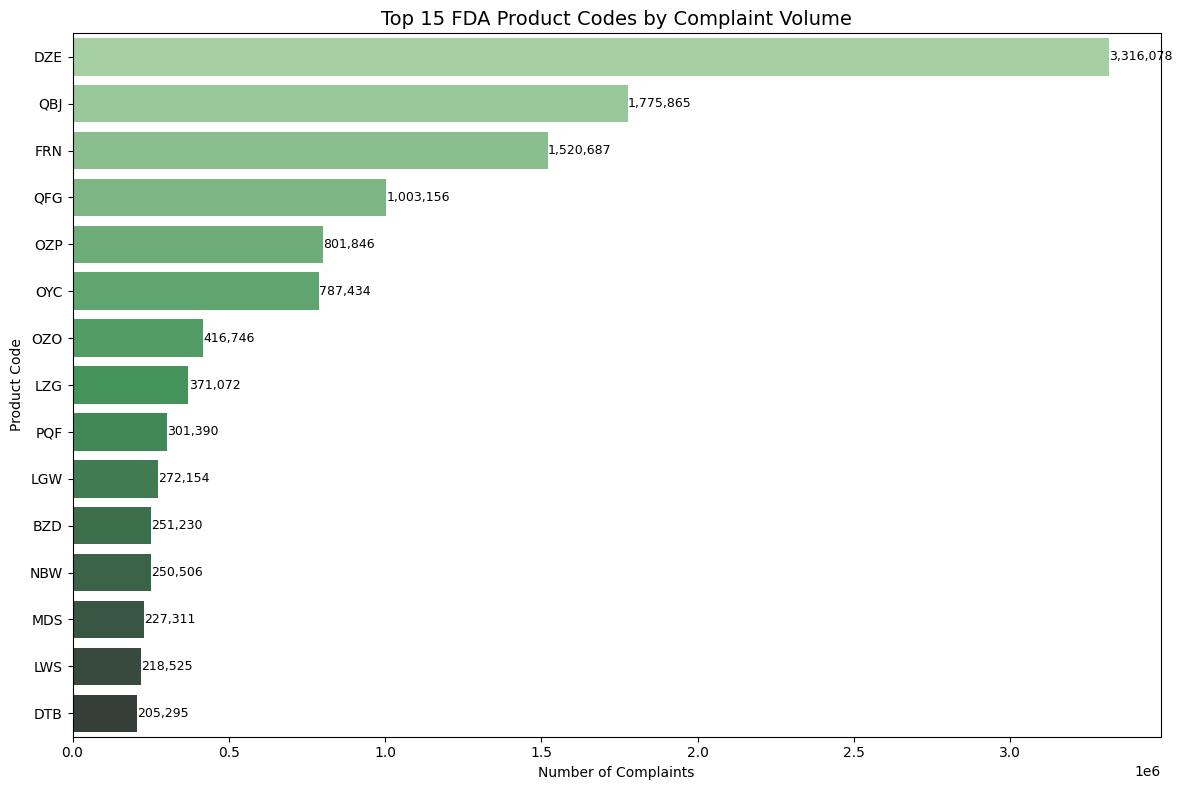

In [12]:
top_codes = df.groupby('DEVICE_REPORT_PRODUCT_CODE').size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)\
    .head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_codes, x='count', 
            y='DEVICE_REPORT_PRODUCT_CODE', palette='Greens_d')
plt.title('Top 15 FDA Product Codes by Complaint Volume', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Product Code')

for i, v in enumerate(top_codes['count']):
    plt.text(v + 500, i, f"{v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_product_codes.png', dpi=150)
plt.show()

In [13]:
pump_df = df[df['GENERIC_NAME'] == 'PUMP, INFUSION'].copy()

print(f"Total Pump, Infusion complaints: {pump_df.shape[0]:,}")
print(f"\nBy year:")
print(pump_df.groupby('YEAR').size().sort_index())

Total Pump, Infusion complaints: 1,447,939

By year:
YEAR
2015      6218
2016      2612
2017      4073
2018      9693
2019      9625
2020     84509
2021    188124
2022    874840
2023    164943
2024     53219
2025     50083
dtype: int64


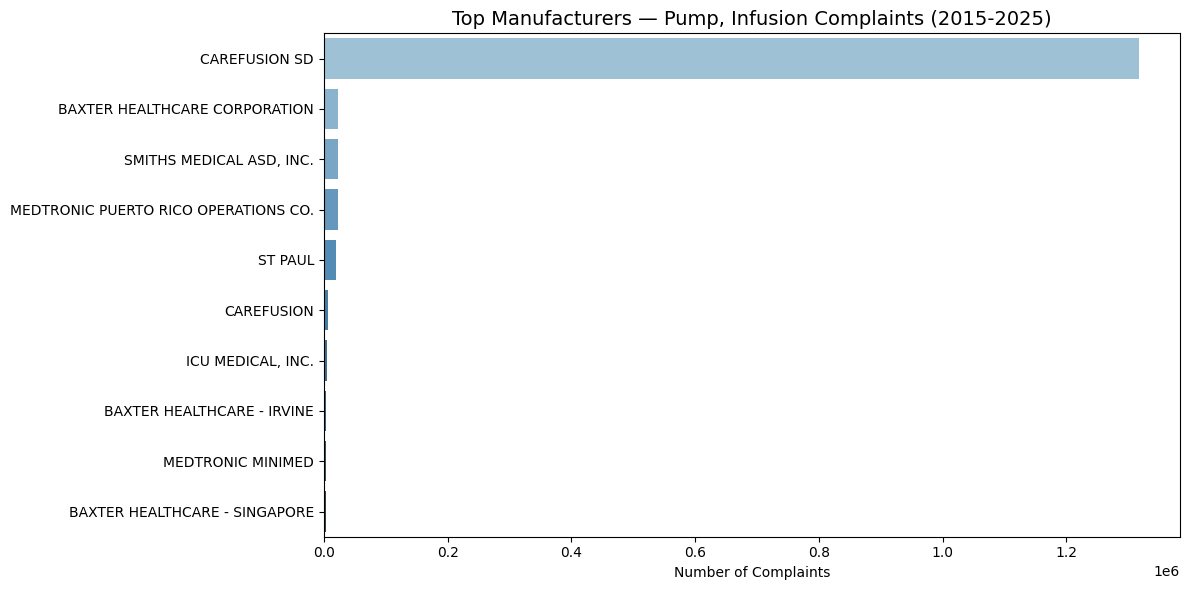

In [14]:
# Top manufacturers for Pump, Infusion
pump_mfr = pump_df.groupby('MANUFACTURER_D_NAME').size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)\
    .head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=pump_mfr, x='count', y='MANUFACTURER_D_NAME', palette='Blues_d')
plt.title('Top Manufacturers — Pump, Infusion Complaints (2015-2025)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('')
plt.tight_layout()
plt.savefig('pump_infusion_manufacturers.png', dpi=150)
plt.show()

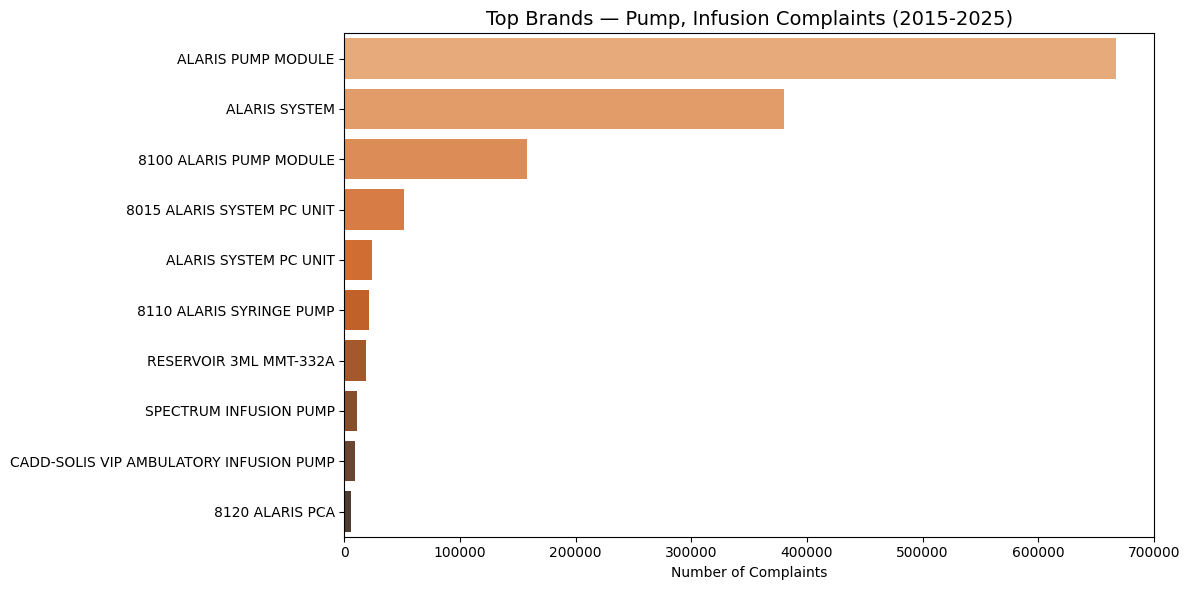

In [15]:
pump_brand = pump_df.groupby('BRAND_NAME').size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)\
    .head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=pump_brand, x='count', y='BRAND_NAME', palette='Oranges_d')
plt.title('Top Brands — Pump, Infusion Complaints (2015-2025)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('')
plt.tight_layout()
plt.savefig('pump_infusion_brands.png', dpi=150)
plt.show()

In [16]:
# Zoom in on 2022 spike - who caused it?
pump_2022 = pump_df[pump_df['YEAR'] == 2022]\
    .groupby('MANUFACTURER_D_NAME').size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)\
    .head(10)

print("2022 Pump, Infusion complaints by manufacturer:")
print(pump_2022.to_string())

2022 Pump, Infusion complaints by manufacturer:
                     MANUFACTURER_D_NAME   count
24                         CAREFUSION SD  852706
90                               ST PAUL   11292
7          BAXTER HEALTHCARE CORPORATION    5928
85              SMITHS MEDICAL ASD, INC.    2214
49  MEDTRONIC PUERTO RICO OPERATIONS CO.    1601
31           ICU MEDICAL COSTA RICA LTD.     217
6                   B.BRAUN MELSUNGEN AG     199
23                  CAREFUSION 303, INC.      75
48                     MEDTRONIC MINIMED      62
5                  B. BRAUN MELSUNGEN AG      54


In [17]:
carefusion_2022 = pump_df[
    (pump_df['MANUFACTURER_D_NAME'] == 'CAREFUSION SD') & 
    (pump_df['YEAR'] == 2022)
]

print(f"CareFusion 2022 complaints: {carefusion_2022.shape[0]:,}")

for text in carefusion_2022['FOI_TEXT'].dropna().sample(5, random_state=42):
    print(text[:300])
    print("---")

CareFusion 2022 complaints: 852,706
the information provided was obtained from a retrospective review of servicing data therefore no other information is obtainable at this time there was no reported patient involvement it was reported that a failure was observed during a planned preventive maintenance or recall remediation service ev
---
the information provided was obtained from a retrospective review of servicing data therefore no other information is obtainable at this time there was no reported patient involvement it was reported that a failure was observed during a planned preventive maintenance or recall remediation service ev
---
a device history record review is performed on each device reported in a mdr reportable event along with other methods of investigation as coded in this mdr report per fiii the information provided was obtained from servicing activities performed on the device there were no additional details obtain
---
it was reported that a failure was observed durin

In [18]:
pump_2022_brands = pump_df[pump_df['YEAR'] == 2022]\
    .groupby('BRAND_NAME').size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)\
    .head(10)\
    .reset_index(drop=True)

print(pump_2022_brands)

                   BRAND_NAME   count
0          ALARIS PUMP MODULE  569334
1               ALARIS SYSTEM  142615
2     8100 ALARIS PUMP MODULE   91409
3  8015 ALARIS SYSTEM PC UNIT   30054
4    8110 ALARIS SYRINGE PUMP    9218
5       ALARIS SYSTEM PC UNIT    7003
6      SPECTRUM INFUSION PUMP    3816
7             8120 ALARIS PCA    2267
8   SPECTRUM IQ INFUSION PUMP    1860
9                        CADD    1809
